# Processamento Digital de Sinais

## Atividade: Filtro FIR

# Universidade Federal de Campina Grande

<img src="https://ccbs.ufcg.edu.br/images/Logomarcas/UFCG_JPEG.png" width="30%">

### Aluno: Eduardo Henrique de Freitas Coura
### Professor: Dr. Edmar Candeia Gurjão
### Data: 19/02/2026

#### Bibliotecas importadas


In [74]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy import signal

#### Funções Criadas

In [75]:
def extrair_frequencias(magnitude, frequencias, limiar = 0.01):
    picos_frequencias = [] # Array para armazenar as frequencias que têm picos
    limite = np.max(magnitude) * limiar # Limite para desprezar o ruído

    for i in range(1, len(magnitude)-1): # Loop que itera sobre o array de magnitudes
        if magnitude[i] > magnitude[i-1] and magnitude[i] > magnitude[i+1]: # Condicional para ver se uma componente de frequência é maior que suas vizinhas
            if magnitude[i] >= limite: # Caso seja maior que suas vizinhas e seja maior que o limite
                picos_frequencias.append(i) # Armazena o índice na lista de frequencias de pico

    return frequencias[picos_frequencias] # Retorna as componentes de frequências que têm índices nos picos

def banco_filtros(wav, fs, lista_freqs):

    plt.figure(figsize=(12,8)) # Ajusta o tamanho da figura

    for i, f in enumerate(lista_freqs): # para cada frequencia f, há um i indexado a ela
        # Coeficientes do filtro FIR com ordem 201 e banda de passagem de 100 Hz centrada em f
        taps = signal.firwin(201, [f-50, f+50],  fs=fs, pass_zero=False)

        # Filtrando o sinal original
        componente_isolada = signal.lfilter(taps, 1.0, wav)

        # Plotando o resultado separado
        plt.subplot(len(lista_freqs), 1, i+1)
        plt.plot(componente_isolada[:500]) # Mostra os primeiros 500 pontos
        plt.title(f"Componente Isolada: {f:.2f} Hz")

    plt.tight_layout()
    plt.show()


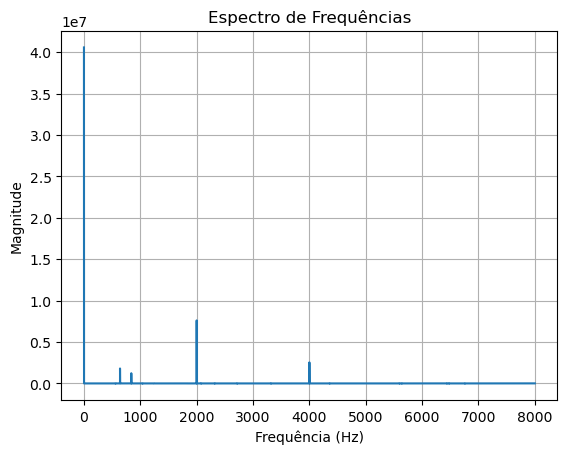

In [76]:
fs, wav = wavfile.read(r"C:\Users\eduar\OneDrive\Área de Trabalho\sinal_1.wav") 
# Extraio a partir desse caminho o arquivo e armazeno o array de amostras em wav e a taxa de amostragem em fs
N = len(wav) # Armazeno em N o tamanho do array de amostras

frequencias = np.fft.rfftfreq(N, 1/fs) # Faço o eixo de frequencias a partir do número de amostras e da taxa de amostragem 
magnitude = np.abs(np.fft.rfft(wav)) # Faço a FFT do sinal e pego o valor absoluto de cada componente de frequência

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.title("Espectro de Frequências")

plt.plot(frequencias, magnitude)
plt.show()

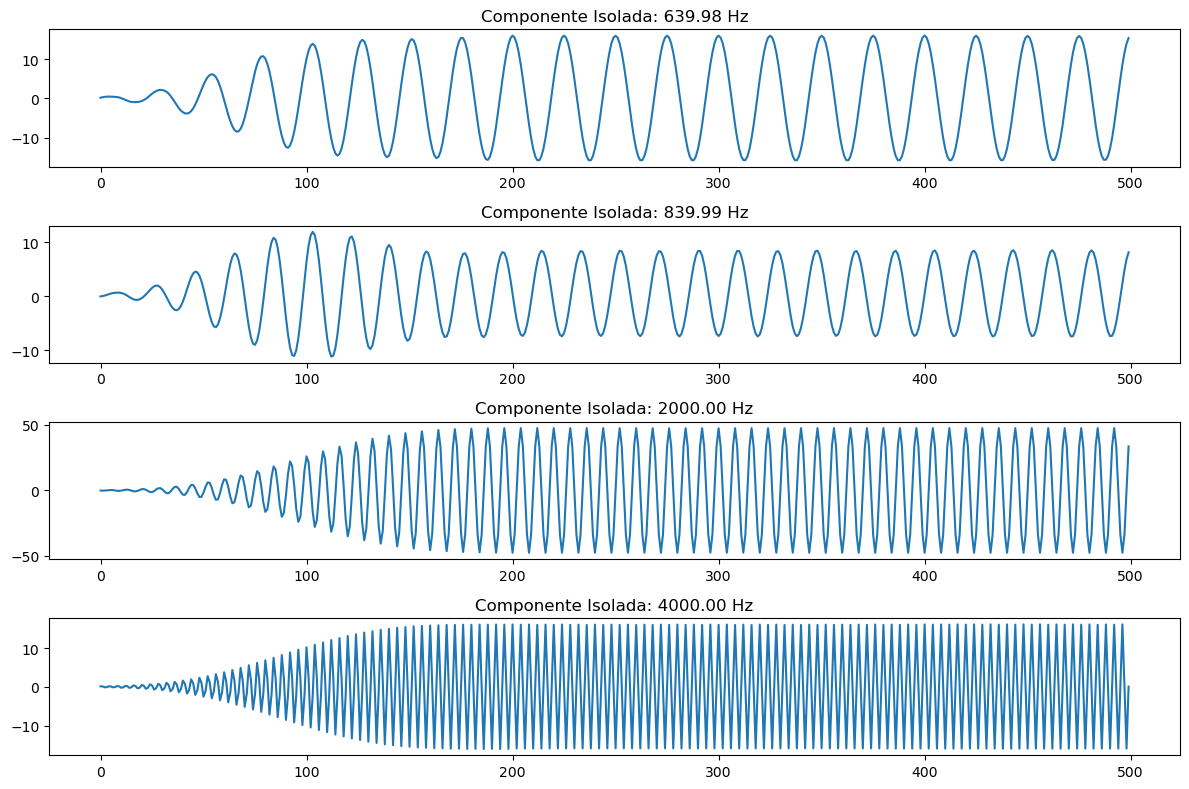

In [77]:
lista_freqs = extrair_frequencias(magnitude, frequencias)

banco_filtros(wav, fs, lista_freqs)

## Base Teórica

A estrutura de filtros digitais não recursivos deriva da forma padrão da equação de diferenças, porém sem a realimentação. Isto é, sem os termos que possuem $a_i$.

Filtros não recursivos são então caracterizados por uma equação de diferenças dada por:

$$ y(n) = \sum_{l=0}^{M} b_l x(n-l) $$

No qual, os coeficientes $b_l$ se relacionam diretamente com a resposta ao impulso do sistema, isto é, $b_l = h(l)$.
Sendo assim, podemos escrever a equação de diferenças como sendo: 

$$ \sum_{l=0}^{M} h(l) x(n-l) $$

E aplicando a transformada Z de ambos os lados da equação e escrevendo a saída dividida pela entrada, obtemos a transformada Z da equação do filtro.

$$H(z) = \frac{Y(z)}{X(z)} = \sum_{l=0}^{M} b_l z^{-l} = \sum_{l=0}^{M} h(l) z^{-l}$$

Ao converter essa equação para o domínio discreto e exigindo que a fase seja linear a equação se torna:

$$h(n) = (-1)^{k} h(M-n), \quad k \in \mathbb{Z}$$

Sabendo diso, há 4 tipos diferentes de filtros:

1. k = 0, M par

2. k = 0, M ímpar

3. k = 1, M par

4. k = 1, M ímpar

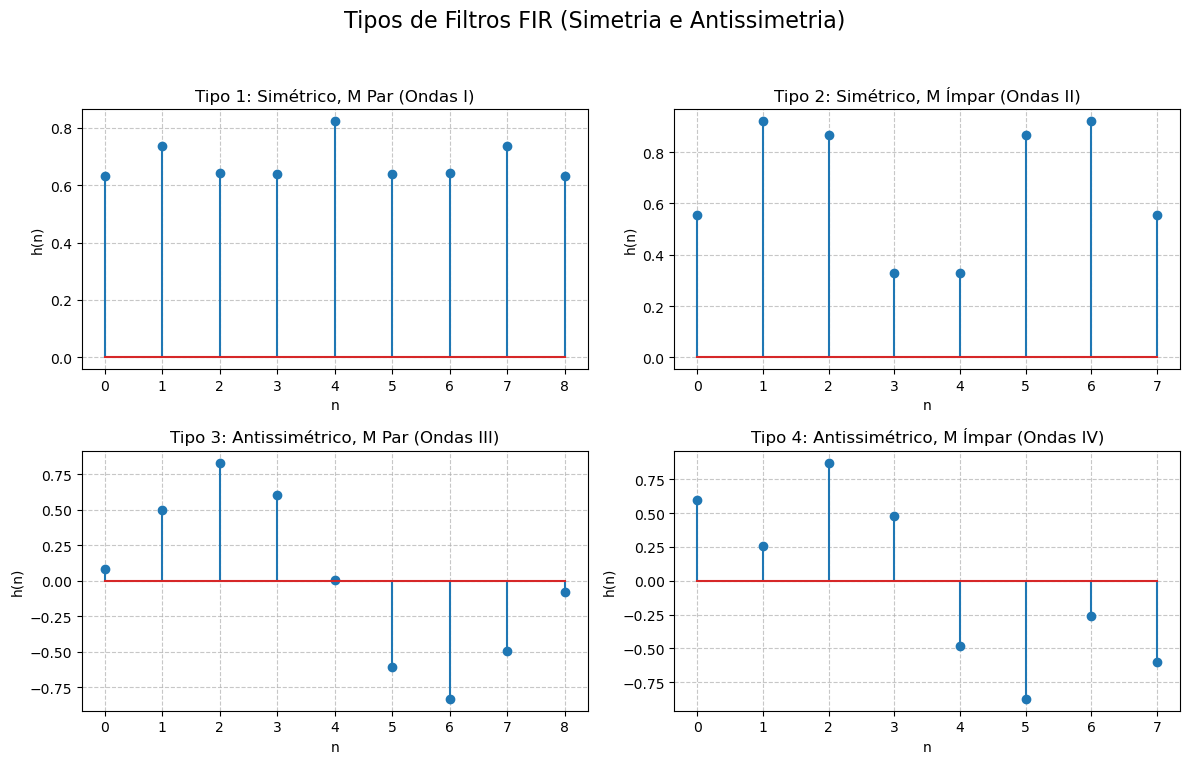

In [87]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Tipos de Filtros FIR (Simetria e Antissimetria)', fontsize=16)

def plot_fir(ax, M, k, titulo):
    n = np.arange(M + 1)
    # Criando uma resposta ao impulso aleatória para a primeira metade
    half = (M // 2) + 1
    h_half = np.random.rand(half)
    
    # Aplicando a condição: h(n) = (-1)^k * h(M-n)
    h = np.zeros(M + 1)
    h[:half] = h_half
    for i in range(half, M + 1):
        h[i] = ((-1)**k) * h[M - i]
        
    ax.stem(n, h)
    ax.set_title(titulo)
    ax.set_xlabel('n')
    ax.set_ylabel('h(n)')
    ax.grid(True, linestyle='--', alpha=0.7)

# Tipo 1: k=0 (Simétrico), M par (M=8 -> 9 amostras)
plot_fir(axs[0, 0], 8, 0, "Tipo 1: Simétrico, M Par (Ondas I)")

# Tipo 2: k=0 (Simétrico), M ímpar (M=7 -> 8 amostras)
plot_fir(axs[0, 1], 7, 0, "Tipo 2: Simétrico, M Ímpar (Ondas II)")

# Tipo 3: k=1 (Antissimétrico), M par (M=8 -> 9 amostras)
plot_fir(axs[1, 0], 8, 1, "Tipo 3: Antissimétrico, M Par (Ondas III)")

# Tipo 4: k=1 (Antissimétrico), M ímpar (M=7 -> 8 amostras)
plot_fir(axs[1, 1], 7, 1, "Tipo 4: Antissimétrico, M Ímpar (Ondas IV)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()